In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import re, unicodedata, random
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
!wget -nc https://download.pytorch.org/tutorial/data.zip
!unzip -n data.zip

# Data

In [ ]:
data_path = "/kaggle/working/data/eng-fra.txt"

In [ ]:
# Normalize string
def normalize(s):
    s = unicodedata.normalize('NFD', s.lower().strip())
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s

In [ ]:
# Language indexer
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2idx = {"<PAD>":0, "<SOS>":1, "<EOS>":2}
        self.idx2word = {0:"<PAD>", 1:"<SOS>", 2:"<EOS>"}
        self.n_words = 3

    def add_sentence(self, sentence):
        for word in sentence.split(" "):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.n_words
            self.idx2word[self.n_words] = word
            self.n_words += 1

In [ ]:
# Prepare dataset
def read_langs(path, reverse=False):
    lines = open(path, encoding='utf-8').read().strip().split('\n')
    pairs = [[normalize(s) for s in l.split('\t')[:2]] for l in lines]
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang, output_lang = Lang("eng"), Lang("fra")
    else:
        input_lang, output_lang = Lang("fra"), Lang("eng")
    return input_lang, output_lang, pairs

MAX_LEN = 15
input_lang, output_lang, pairs = read_langs('/content/data/eng-fra.txt', reverse=True)

# Filter long sentences
pairs = [p for p in pairs if len(p[0].split(" ")) < MAX_LEN and len(p[1].split(" ")) < MAX_LEN]

In [ ]:
from collections import Counter

# Count word frequencies across all pairs
all_words = [w for src, tgt in pairs for w in src.split() + tgt.split()]
word_counts = Counter(all_words)

# Keep the top-N most common words
N = 20000
most_common = {w for w, _ in word_counts.most_common(N)}

# Replace rare words with <UNK>
UNK = "<UNK>"
pairs = [
    (
        " ".join([w if w in most_common else UNK for w in src.split()]),
        " ".join([w if w in most_common else UNK for w in tgt.split()])
    )
    for src, tgt in pairs
]

In [ ]:
# Build vocab from filtered pairs
for src, tgt in pairs:
    input_lang.add_sentence(src)
    output_lang.add_sentence(tgt)


print(f"Dataset size: {len(pairs)} pairs")

Dataset size: 129685 pairs


In [ ]:
# view samples of dataset
for i in range(10):
    print(random.choice(pairs))

('c a pourrait ne pas suffire.', 'it might not be enough.')
('quelle quantite de nourriture donnez vous a manger a votre chien ?', 'how much do you feed your dog?')
('tom s est porte volontaire pour payer les <UNK>', 'tom volunteered to pay for the damages.')
('ne raccrochez pas et attendez un moment s il vous plait.', 'hold the line please.')
('il n y a pas cours en aou t.', 'there is no school during august.')
('un e norme cri d encouragement s e leva de la foule.', 'a <UNK> cheer burst from the crowd.')
('tu ne sais jamais quand c a se re ve <UNK> utile.', 'you never know when this might come in handy.')
('c est moi qui suis tellement malade.', 'i am so sick.')
('ce n est pas trop profond.', 'it s not too deep.')
('j ai perdu ma montre.', 'i lost my watch.')


In [ ]:
# select a subset of the whole dataset
pairs = pairs[:129685]
len(pairs)

129685

In [ ]:
random.shuffle(pairs)
train_size = int(0.7 * len(pairs))
val_size   = int(0.2 * len(pairs))
train_pairs = pairs[:train_size]
val_pairs   = pairs[train_size:train_size+val_size]
test_pairs  = pairs[train_size+val_size:]

In [ ]:
def indexes_from_sentence(lang, sentence):
    return [lang.word2idx["<SOS>"]] + [lang.word2idx[w] for w in sentence.split(" ")] + [lang.word2idx["<EOS>"]]

class TranslationDataset(Dataset):
    def __init__(self, pairs, input_lang, output_lang, to_sort = True):
        # Curriculum: sort by input length
        if to_sort:
          self.pairs = sorted(pairs, key=lambda x: len(x[0].split()))
        else:
          self.pairs = pairs
        self.input_lang = input_lang
        self.output_lang = output_lang

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_idx = indexes_from_sentence(self.input_lang, src)
        tgt_idx = indexes_from_sentence(self.output_lang, tgt)
        return torch.tensor(src_idx), torch.tensor(tgt_idx)

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    srcs = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=0)
    tgts = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=0)
    return srcs, tgts

## Dataloading

In [ ]:
# creating datasets and dataloaders
train_dataset = TranslationDataset(train_pairs, input_lang, output_lang, to_sort=False)
val_dataset = TranslationDataset(val_pairs, input_lang, output_lang, to_sort=False)
test_dataset = TranslationDataset(test_pairs, input_lang, output_lang, to_sort=False)

dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# Models

In [ ]:
class EncoderBILSTM(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, dropout: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=2,
            dropout=dropout,
            bidirectional=True,
            batch_first=True
        )
        # linear to project bidirectional hidden -> decoder hidden
        self.fc = nn.Linear(hidden_size*2, hidden_size)

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))
        packed_input = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_output, (hidden, cell) = self.rnn(packed_input)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)

        # hidden/cell shapes: (num_layers*2, B, H)
        hidden = self._cat_directions(hidden)  # (num_layers, B, 2H)
        cell   = self._cat_directions(cell)    # (num_layers, B, 2H)

        # project down to (num_layers, B, H)
        hidden = torch.tanh(self.fc(hidden))
        cell   = torch.tanh(self.fc(cell))

        return outputs, (hidden, cell)

    def _cat_directions(self, states):
        """Convert (num_layers*2, B, H) -> (num_layers, B, 2H)."""
        num_layers = states.size(0) // 2
        batch_size, hidden_size = states.size(1), states.size(2)
        states = states.view(num_layers, 2, batch_size, hidden_size)
        states = torch.cat((states[:,0], states[:,1]), dim=2)  # concat forward/backward
        return states


In [ ]:
class DecoderBILSTM(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, dropout: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=2,
            dropout=dropout,
            batch_first=True
        )
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_step, hidden_cell):
        hidden, cell = hidden_cell
        embedded = self.dropout(self.embedding(input_step))
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))  # (B, V)
        return prediction, (hidden, cell)


In [ ]:
class Seq2SeqBILSTM(nn.Module):
  def __init__(self, encoder, decoder, device):
      super().__init__()
      self.encoder = encoder
      self.decoder = decoder
      self.device = device

  def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.0):
      # Encoder returns outputs and (hidden, cell)
      encoder_outputs, (hidden, cell) = self.encoder(src, src_lengths)

      # First input to decoder is <SOS>
      input_step = tgt[:, 0].unsqueeze(1)   # (B, 1)
      outputs = []

      for t in range(1, tgt.size(1)):
          pred, (hidden, cell) = self.decoder(input_step, (hidden, cell))
          outputs.append(pred.unsqueeze(1))

          # Greedy decode vs teacher forcing
          teacher_force = random.random() < teacher_forcing_ratio
          top1 = pred.argmax(1).unsqueeze(1)
          input_step = tgt[:, t].unsqueeze(1) if teacher_force else top1

      return torch.cat(outputs, dim=1)   # (B, T-1, V)


In [ ]:
class EncoderLSTM(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, dropout: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=2,
            dropout=dropout,
            bidirectional=False,   # unidirectional
            batch_first=True
        )

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))
        packed_input = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_output, (hidden, cell) = self.rnn(packed_input)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        return outputs, (hidden, cell)


In [ ]:
class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, dropout: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=2,
            dropout=dropout,
            batch_first=True
        )
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_step, hidden_cell):
        hidden, cell = hidden_cell
        embedded = self.dropout(self.embedding(input_step))
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))  # (B, V)
        return prediction, (hidden, cell)


In [ ]:
class Seq2SeqLSTM(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.0):
        # Encoder
        encoder_outputs, (hidden, cell) = self.encoder(src, src_lengths)

        # First input to decoder = <SOS>
        input_step = tgt[:, 0].unsqueeze(1)   # shape (B, 1)
        outputs = []

        for t in range(1, tgt.size(1)):
            # Step decode
            pred, (hidden, cell) = self.decoder(input_step, (hidden, cell))
            outputs.append(pred.unsqueeze(1))

            # Greedy decoding (no teacher forcing unless ratio > 0)
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = pred.argmax(1).unsqueeze(1)
            input_step = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return torch.cat(outputs, dim=1)   # (B, T-1, V)


In [ ]:
class EncoderRNN(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, dropout: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.RNN(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=2,
            dropout=dropout,
            bidirectional=False,   # unidirectional
            batch_first=True
        )

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))
        packed_input = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_output, hidden = self.rnn(packed_input)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        # outputs: (B, T, H), hidden: (num_layers, B, H)
        return outputs, hidden


In [ ]:
class DecoderRNN(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, dropout: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.RNN(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=2,
            dropout=dropout,
            batch_first=True
        )
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_step, hidden):
        embedded = self.dropout(self.embedding(input_step))   # (B, 1, H)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc_out(output.squeeze(1))  # (B, V)
        return prediction, hidden


In [ ]:
class Seq2SeqRNN(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.0):
        encoder_outputs, hidden = self.encoder(src, src_lengths)

        # First input to decoder is <SOS>
        input_step = tgt[:, 0].unsqueeze(1)
        outputs = []

        for t in range(1, tgt.size(1)):
            pred, hidden = self.decoder(input_step, hidden)
            outputs.append(pred.unsqueeze(1))

            # greedy vs teacher forcing
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = pred.argmax(1).unsqueeze(1)
            input_step = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return torch.cat(outputs, dim=1)  # (B, T-1, V)


In [ ]:
class EncoderBIRNN(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, dropout: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.RNN(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=2,
            dropout=dropout,
            bidirectional=True,   # bidirectional
            batch_first=True
        )
        # project concatenated forward+backward into decoder hidden
        self.fc = nn.Linear(hidden_size*2, hidden_size)

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))
        packed_input = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_output, hidden = self.rnn(packed_input)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)

        hidden = self._cat_directions(hidden)   # (num_layers, B, 2H)
        hidden = torch.tanh(self.fc(hidden))    # (num_layers, B, H)

        return outputs, hidden

    def _cat_directions(self, hidden):
        num_layers = hidden.size(0) // 2
        hidden = hidden.view(num_layers, 2, hidden.size(1), hidden.size(2))
        return torch.cat((hidden[:,0], hidden[:,1]), dim=2)


In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.0):
        encoder_outputs, hidden = self.encoder(src, src_lengths)

        # First input to decoder is <SOS>
        input_step = tgt[:, 0].unsqueeze(1)
        outputs = []

        for t in range(1, tgt.size(1)):
            pred, hidden = self.decoder(input_step, hidden)
            outputs.append(pred.unsqueeze(1))

            # greedy vs teacher forcing
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = pred.argmax(1).unsqueeze(1)
            input_step = tgt[:, t].unsqueeze(1) if teacher_force else top1

        return torch.cat(outputs, dim=1)  # (B, T-1, V)


# Execution

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    epoch_loss = 0
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)

        # compute true lengths of source (before padding)
        src_lengths = (src != 0).sum(dim=1).to(device)

        optimizer.zero_grad()
        output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.0)

        # reshape for CE loss
        output_dim = output.size(-1)
        loss = criterion(output.reshape(-1, output_dim), tgt[:, 1:].reshape(-1))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(dataloader)

In [ ]:
import editdistance

def calculate_wer_cer(reference: str, hypothesis: str):
    """
    Compute Word Error Rate (WER) and Character Error Rate (CER)
    between a reference and a hypothesis string.

    Args:
        reference (str): the ground-truth sentence
        hypothesis (str): the predicted sentence

    Returns:
        wer (float): word error rate (0.0 to 1.0)
        cer (float): character error rate (0.0 to 1.0)
    """
    # Split into words
    ref_words, hyp_words = reference.split(), hypothesis.split()

    # Word-level edit distance
    word_error = editdistance.eval(ref_words, hyp_words)
    wer = word_error / len(ref_words) if ref_words else 0.0

    # Character-level edit distance
    char_error = editdistance.eval(reference, hypothesis)
    cer = char_error / len(reference) if reference else 0.0

    return wer, cer

In [ ]:
def evaluate(model, dataloader, criterion, device, idx2word, num_samples=5):
    model.eval()
    epoch_loss, total_wer, total_cer = 0, 0, 0
    samples = []

    with torch.no_grad():
        for i, (src, tgt) in enumerate(dataloader):
            src, tgt = src.to(device), tgt.to(device)
            src_lengths = (src != 0).sum(dim=1).to(device)

            output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.5)

            output_dim = output.size(-1)
            loss = criterion(output.reshape(-1, output_dim), tgt[:, 1:].reshape(-1))
            epoch_loss += loss.item()

            # decode predictions
            preds = output.argmax(-1)  # [B, T-1]
            for j in range(min(len(src), num_samples)):
                ref = " ".join([idx2word[idx.item()] for idx in tgt[j] if idx.item() not in [0,1,2]])
                hyp = " ".join([idx2word[idx.item()] for idx in preds[j] if idx.item() not in [0,1,2]])
                wer, cer = calculate_wer_cer(ref, hyp)
                total_wer += wer
                total_cer += cer
                if i < 1:  # print only first batch
                    samples.append((ref, hyp, wer, cer))

    return (epoch_loss / len(dataloader),
            total_wer / len(dataloader.dataset),
            total_cer / len(dataloader.dataset),
            samples)

In [ ]:
INPUT_DIM = input_lang.n_words     # source vocab size
OUTPUT_DIM = output_lang.n_words   # target vocab size
HIDDEN_SIZE = 512 #256
DROPOUT = 0.0
LEARNING_RATE = 0.0001

# encoder = Encoder(INPUT_DIM, HIDDEN_SIZE, dropout=DROPOUT)
# decoder = Decoder(OUTPUT_DIM, HIDDEN_SIZE, dropout=DROPOUT)
# model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)
# encoder = EncoderLSTM(INPUT_DIM, HIDDEN_SIZE, dropout=DROPOUT)
# decoder = DecoderLSTM(OUTPUT_DIM, HIDDEN_SIZE, dropout=DROPOUT)
# model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)
# encoder = EncoderBIRNN(INPUT_DIM, HIDDEN_SIZE, dropout=DROPOUT)
# decoder = DecoderRNN(OUTPUT_DIM, HIDDEN_SIZE, dropout=DROPOUT)
# model = Seq2SeqRNN(encoder, decoder, DEVICE).to(DEVICE)

encoder = EncoderBILSTM(INPUT_DIM, HIDDEN_SIZE, dropout=DROPOUT)
decoder = DecoderBILSTM(OUTPUT_DIM, HIDDEN_SIZE, dropout=DROPOUT)
model   = Seq2SeqBILSTM(encoder, decoder, DEVICE).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=output_lang.word2idx["<PAD>"])
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# For later decoding
idx2word = output_lang.idx2word

EPOCHS=30

In [ ]:
train_losses, val_losses, val_wers, val_cers = [], [], [], []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, dataloader, criterion, optimizer, DEVICE)
    val_loss, val_wer, val_cer, samples = evaluate(model, val_dataloader, criterion, DEVICE, idx2word)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_wers.append(val_wer)
    val_cers.append(val_cer)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f" Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f" Val WER: {val_wer*100:.2f}% | Val CER: {val_cer*100:.2f}%")
    print("="*50)

    for k, (ref, hyp, wer, cer) in enumerate(samples):
        print(f"Sample {k+1}")
        print(f" R: {ref}")
        print(f" H: {hyp}")
        print(f" WER: {wer*100:.2f}%, CER: {cer*100:.2f}%")
        print("-"*50)

Epoch 1/30
 Train Loss: 5.0473 | Val Loss: 4.4573
 Val WER: 5.86% | Val CER: 5.17%
Sample 1
 R: i don t know why he quit the company.
 H: i don t t to to to to
 WER: 66.67%, CER: 62.16%
--------------------------------------------------
Sample 2
 R: are you old enough to vote?
 H: do you you to the
 WER: 66.67%, CER: 55.56%
--------------------------------------------------
Sample 3
 R: he is <UNK> and has no brothers or sisters.
 H: he is t to to to to to to to
 WER: 88.89%, CER: 65.12%
--------------------------------------------------
Sample 4
 R: i ll be there at two o clock without fail.
 H: i have a a the the
 WER: 90.00%, CER: 73.81%
--------------------------------------------------
Sample 5
 R: she was overcome with happiness.
 H: she was a a
 WER: 60.00%, CER: 68.75%
--------------------------------------------------
Epoch 2/30
 Train Loss: 4.1445 | Val Loss: 3.9182
 Val WER: 5.22% | Val CER: 4.82%
Sample 1
 R: i don t know why he quit the company.
 H: i don t know he he he t

In [ ]:
def plot_metrics(train_losses, val_losses, val_wers, val_cers):
    """
    Plots training & validation loss, and validation WER & CER,
    and saves the plot to a file.
    """
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))

    # --- Subplot 1: Training and Validation Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-o', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    # plt.ylim(1.0, 5.2)  # Set the Y-axis range for the first plot
    plt.legend()
    plt.grid(True)

    # --- Subplot 2: Word Error Rate (WER) and Character Error Rate (CER) ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_wers, 'b-o', label='Validation WER')
    plt.plot(epochs, val_cers, 'r-o', label='Validation CER')
    plt.title('Validation WER and CER')
    plt.xlabel('Epochs')
    plt.ylabel('Error Rate') # Corrected label
    # plt.ylim(, 5.2)  # Set the Y-axis range for the second plot
    plt.legend()
    plt.grid(True)

    # --- Finalize and Save ---
    plt.tight_layout()
    plt.savefig('training_metrics.png')
    # plt.show() # In many environments, savefig() is preferred.
    print("\n'training_metrics.png' has been generated.")


'training_metrics.png' has been generated.


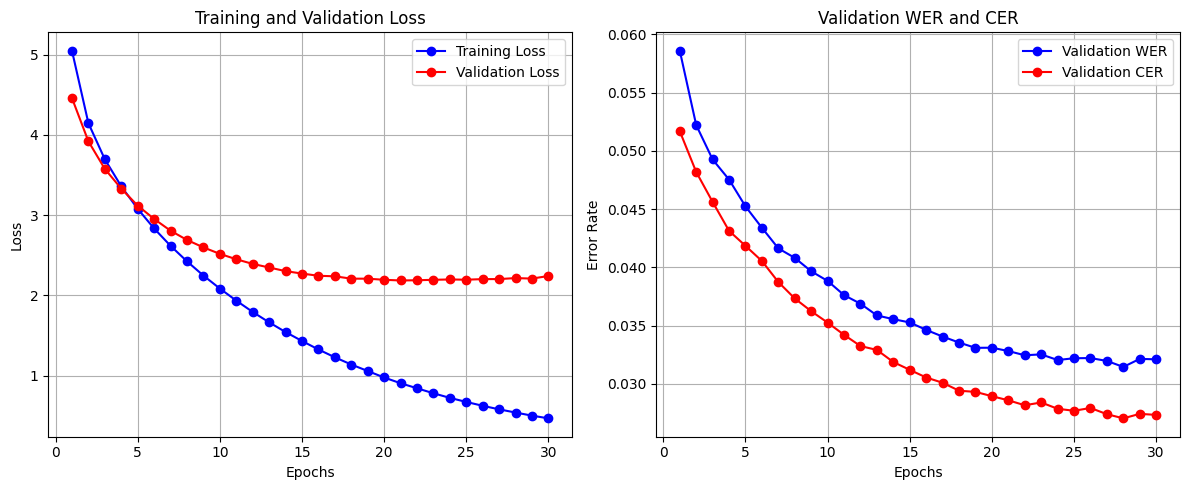

In [ ]:
plot_metrics(train_losses, val_losses, val_wers, val_cers)

In [ ]:
def test_model(model, dataloader, input_lang, output_lang, device, num_samples=5):
    model.eval()
    samples = []
    total_wer, total_cer, count = 0.0, 0.0, 0

    idx2word_in = input_lang.idx2word
    idx2word_out = output_lang.idx2word

    with torch.no_grad():
        for i, (src, tgt) in enumerate(dataloader):
            src, tgt = src.to(device), tgt.to(device)
            src_lengths = (src != 0).sum(dim=1).to(device)

            # Greedy decode: no teacher forcing
            output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.0)
            preds = output.argmax(-1)  # [B, T-1]

            for j in range(src.size(0)):
                # Convert indices -> words (ignore PAD=0, SOS=1, EOS=2)
                fr_sent = " ".join([idx2word_in[idx.item()] for idx in src[j] if idx.item() not in [0]])
                en_ref  = " ".join([idx2word_out[idx.item()] for idx in tgt[j] if idx.item() not in [0,1,2]])
                en_hyp  = " ".join([idx2word_out[idx.item()] for idx in preds[j] if idx.item() not in [0,1,2]])

                wer, cer = calculate_wer_cer(en_ref, en_hyp)
                total_wer += wer
                total_cer += cer
                count += 1

                if len(samples) < num_samples:
                    samples.append((fr_sent, en_ref, en_hyp, wer, cer))

    # Print some samples
    print("--- Testing Samples ---")
    for k, (fr, ref, hyp, wer, cer) in enumerate(samples, 1):
        print(f"Sample {k}")
        print(f" French    : {fr}")
        print(f" Reference : {ref}")
        print(f" Prediction: {hyp}")
        print(f" WER: {wer*100:.2f}% | CER: {cer*100:.2f}%")
        print("-"*60)

    avg_wer = total_wer / max(count, 1)
    avg_cer = total_cer / max(count, 1)
    print(f"\n--- Overall ---")
    print(f" Avg WER: {avg_wer*100:.2f}%")
    print(f" Avg CER: {avg_cer*100:.2f}%")
    return avg_wer, avg_cer

In [ ]:
test_model(model, test_dataloader, input_lang, output_lang, DEVICE, num_samples=10)

--- Testing Samples ---
Sample 1
 French    : <SOS> c est un vrai poids en moins sur mon esprit. <EOS>
 Reference : that s a real <UNK> off my mind.
 Prediction: it s a bit bit in in in my my
 WER: 87.50% | CER: 68.75%
------------------------------------------------------------
Sample 2
 French    : <SOS> les halte res sont <UNK> <EOS>
 Reference : the <UNK> are heavy.
 Prediction: the <UNK> are <UNK>
 WER: 25.00% | CER: 30.00%
------------------------------------------------------------
Sample 3
 French    : <SOS> il vaut mieux pe cher par exce s de prudence. <EOS>
 Reference : it s better to err on the side of caution.
 Prediction: he must better better the the next air.
 WER: 80.00% | CER: 57.14%
------------------------------------------------------------
Sample 4
 French    : <SOS> les <UNK> ont souvent du mal a se faire de nouveaux amis. <EOS>
 Reference : <UNK> often find it difficult to make new friends.
 Prediction: the <UNK> often helped to make many friends.
 WER: 55.56% | 

(0.4117444241316531, 0.3457739607357772)